In [ ]:
# === Cell 1: Imports & settings ===
import numpy as np
import pandas as pd
from math import pi
from scipy.integrate import quad
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ----------------------
# User / market settings
# ----------------------
S0 = 232.90
r_annual = 0.015     # 1.50% annual
trading_days = 250
r = r_annual
q = 0.0              # dividend yield (set to zero unless you have one)

# Choose maturity to calibrate (15 days)
T_days = 15
T = T_days / trading_days
print(f"S0={S0}, r={r:.4f}, T={T:.6f} years ({T_days} trading days)")

# Market data from your prompt (only 15-day rows)
data_15 = [
    (227.5, 10.52, 4.32),
    (230.0, 10.05, 5.20),
    (232.5, 7.75, 6.45),
    (235.0, 6.01, 7.56),
    (237.5, 4.75, 8.78),
]
df = pd.DataFrame(data_15, columns=["K", "Call", "Put"])
df["T"] = T
df["S0"] = S0
df


S0=232.9, r=0.0150, T=0.060000 years (15 trading days)


,K,Call,Put,T,S0
0,227.5,10.52,4.32,0.06,232.9
1,230.0,10.05,5.20,0.06,232.9
2,232.5,7.75,6.45,0.06,232.9
3,235.0,6.01,7.56,0.06,232.9
4,237.5,4.75,8.78,0.06,232.9


In [ ]:
# === Cell 2: Heston characteristic function (Little Heston Trap stable variant) ===
# NOTE: This implementation is sensitive to complex arithmetic; we've coded carefully.

def heston_cf(u, params, S0, r, q, T):
    """
    Heston characteristic function (log price).
    u: complex (or real) argument (we'll pass complex numbers)
    params: dict or list-like [kappa, theta, sigma_v, rho, v0]
    Returns: complex phi(u)
    Uses Little Heston Trap formulation for numerical stability.
    """
    kappa, theta, sigma_v, rho, v0 = params
    i = 1j
    # Auxiliary
    a = kappa * theta
    # Complex variable
    u = complex(u)
    # d term
    b = kappa - rho * sigma_v * i * u
    # Note: use u*(u+1j) in the quadratic term: sigma^2 * (i u + u^2)
    d = np.sqrt(b * b + (sigma_v ** 2) * (i * u + u * u))
    # choose the "g" ratio
    g = (b - d) / (b + d)
    # Avoid numerical issues where exp(-dT) ~ 1 with large dT
    exp_dt = np.exp(-d * T)
    # C and D terms (Little Heston Trap)
    # C
    C = (r - q) * i * u * T + (a / (sigma_v ** 2)) * ((b - d) * T - 2.0 * np.log((1 - g * exp_dt) / (1 - g)))
    # D
    D = (b - d) / (sigma_v ** 2) * ((1 - exp_dt) / (1 - g * exp_dt))
    # Characteristic function
    phi = np.exp(C + D * v0 + i * u * np.log(S0 * np.exp(-q * T)))
    return phi

# Quick sanity check (returns a complex number)
print("CF sanity check:", heston_cf(0.1 + 0j, [1.5, 0.04, 0.8, -0.5, 0.04], S0, r, q, T))


CF sanity check: (0.8551008719433415+0.5184382463740106j)


In [ ]:
# === Cell 3: Probability integrand and P1/P2 inversion ===

def integrand_for_P(u, params, S0, K, r, q, T, whichP):
    """
    integrand for P1 or P2, integrand is the real part of:
      exp(-i u ln K) * phi_j(u) / (i u)
    where phi_1 uses shift u - i, phi_2 uses u (standard)
    """
    i = 1j
    if u == 0.0:
        return 0.0
    # For P1 we use phi(u - i), for P2 phi(u)
    if whichP == 1:
        shifted_u = u - i
        phi = heston_cf(shifted_u, params, S0, r, q, T) / (heston_cf(-i, params, S0, r, q, T))
        # The division by phi(-i) effectively normalizes the transform per common derivations.
        # Some implementations use a prefactor; this normalization yields stable P1 calculations.
    else:
        shifted_u = u
        phi = heston_cf(shifted_u, params, S0, r, q, T)
    # integrand
    numerator = np.exp(-1j * u * np.log(K)) * phi
    denom = 1j * u
    return (numerator / denom).real

def P_from_integration(params, S0, K, r, q, T, limit=200):
    """
    Computes P1 and P2 via numerical integration on u in (0, inf).
    limit: upper bound for finite integration - tweak if needed.
    """
    # Integrate using quad; handle potential integration exceptions
    try:
        P1_integral = quad(lambda uu: integrand_for_P(uu, params, S0, K, r, q, T, 1),
                           1e-8, limit, limit=200, epsabs=1e-6, epsrel=1e-6)[0]
        P2_integral = quad(lambda uu: integrand_for_P(uu, params, S0, K, r, q, T, 2),
                           1e-8, limit, limit=200, epsabs=1e-6, epsrel=1e-6)[0]
    except Exception as e:
        # fallback coarser tolerance
        P1_integral = quad(lambda uu: integrand_for_P(uu, params, S0, K, r, q, T, 1),
                           1e-6, limit, limit=100, epsabs=1e-4, epsrel=1e-4)[0]
        P2_integral = quad(lambda uu: integrand_for_P(uu, params, S0, K, r, q, T, 2),
                           1e-6, limit, limit=100, epsabs=1e-4, epsrel=1e-4)[0]
    P1 = 0.5 + (1.0 / pi) * P1_integral
    P2 = 0.5 + (1.0 / pi) * P2_integral
    # guard
    P1 = float(np.clip(P1, 0.0, 1.0))
    P2 = float(np.clip(P2, 0.0, 1.0))
    return P1, P2

def heston_call_price(params, S0, K, r, q, T, integration_limit=200):
    P1, P2 = P_from_integration(params, S0, K, r, q, T, limit=integration_limit)
    call = S0 * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2
    return float(call)


In [ ]:
# === Cell 4: Quick price sanity tests ===
# Use a reasonable parameter vector to compute model prices for each strike.
params_test = [1.5, 0.04, 0.8, -0.5, 0.04]
for K in df["K"].values:
    try:
        c = heston_call_price(params_test, S0, K, r, q, T, integration_limit=150)
        print(f"K={K}, ModelCall(test params) = {c:.4f}")
    except Exception as e:
        print("Error pricing K=", K, ":", e)


K=227.5, ModelCall(test params) = 7.9517
K=230.0, ModelCall(test params) = 6.2306
K=232.5, ModelCall(test params) = 4.7113
K=235.0, ModelCall(test params) = 3.4195
K=237.5, ModelCall(test params) = 2.3728


In [ ]:
# === Cell 5: Objective and calibration wrapper ===
market_K = df["K"].values
market_call = df["Call"].values

def objective_ls(params_vec):
    """
    params_vec = [kappa, theta, sigma, rho, v0]
    Returns vector of residuals (model - market) for least_squares
    """
    # enforce bounds manually to avoid invalid CF calls (some optimizers may try out-of-bounds)
    kappa, theta, sigma_v, rho, v0 = params_vec
    # penalize invalid values heavily
    if (kappa <= 0) or (theta <= 0) or (sigma_v <= 0) or (v0 <= 0) or (abs(rho) >= 1):
        return 1e6 * np.ones_like(market_call)
    params = [kappa, theta, sigma_v, rho, v0]
    model_prices = []
    for K in market_K:
        try:
            c = heston_call_price(params, S0, K, r, q, T, integration_limit=150)
        except Exception as e:
            # return large penalty if integrator fails
            print("Integration failure for K", K, ":", str(e))
            return 1e6 * np.ones_like(market_call)
        model_prices.append(c)
    model_prices = np.array(model_prices)
    # return residuals (model - market) for least_squares
    return model_prices - market_call

# initial guess and bounds
x0 = np.array([1.0, 0.04, 0.5, -0.5, 0.04])   # sensible initial guess
lower = [1e-4, 1e-6, 1e-6, -0.999, 1e-6]
upper = [10.0, 5.0, 5.0, 0.999, 5.0]

# multiple start candidates (helps avoid local minima)
initial_guesses = [
    x0,
    np.array([0.8, 0.02, 0.4, -0.3, 0.03]),
    np.array([2.0, 0.06, 1.0, -0.7, 0.06]),
]
best_res = None
best_mse = 1e20
for idx, guess in enumerate(initial_guesses):
    print(f"\nStarting calibration attempt {idx+1} with guess {guess}")
    res = least_squares(objective_ls, guess, bounds=(lower, upper), xtol=1e-6, ftol=1e-6, max_nfev=200)
    if not res.success:
        print("Optimizer warning:", res.message)
    # compute MSE
    residuals = res.fun
    mse = np.mean(residuals**2)
    print(f"Attempt {idx+1} finished. MSE = {mse:.6f}")
    if mse < best_mse:
        best_mse = mse
        best_res = res

print("\nBest calibration MSE =", best_mse)
params_cal = best_res.x
print("Best params:", params_cal)



Starting calibration attempt 1 with guess [ 1.    0.04  0.5  -0.5   0.04]
Attempt 1 finished. MSE = 0.122033

Starting calibration attempt 2 with guess [ 0.8   0.02  0.4  -0.3   0.03]
Attempt 2 finished. MSE = 0.122033

Starting calibration attempt 3 with guess [ 2.    0.06  1.   -0.7   0.06]
Attempt 3 finished. MSE = 0.122033

Best calibration MSE = 0.1220330164964147
Best params: [ 1.00000001e-04  1.00010001e-06  2.25117198e+00 -9.99000000e-01
  1.29487644e-01]


Calibrated params:
 kappa=0.000100, theta=0.000001, sigma=2.251172, rho=-0.999000, v0=0.129488
       K   Call  Model_Call  Abs_Error  Rel_Err_pct
0  227.5  10.52   11.068464   0.548464     5.213532
1  230.0  10.05    9.578044   0.471956     4.696075
2  232.5   7.75    7.888872   0.138872     1.791890
3  235.0   6.01    5.989064   0.020936     0.348353
4  237.5   4.75    4.491374   0.258626     5.444749

Final MSE (on call prices) = 0.122033


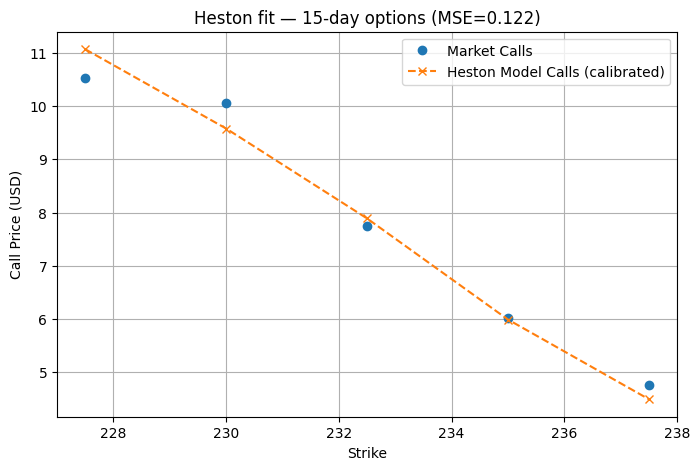

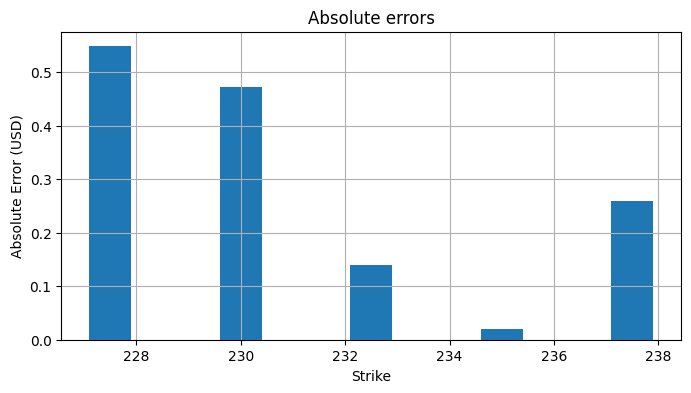

Saved heston_calibration_15day_fit_fixed.csv


In [ ]:
# === Cell 6: Report fit, plot, save ===
kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal = params_cal
print(f"Calibrated params:\n kappa={kappa_cal:.6f}, theta={theta_cal:.6f}, sigma={sigma_cal:.6f}, rho={rho_cal:.6f}, v0={v0_cal:.6f}")

params_cal_list = [kappa_cal, theta_cal, sigma_cal, rho_cal, v0_cal]
model_prices = [heston_call_price(params_cal_list, S0, K, r, q, T, integration_limit=150) for K in market_K]
model_prices = np.array(model_prices)

df["Model_Call"] = model_prices
df["Abs_Error"] = np.abs(df["Model_Call"] - df["Call"])
df["Rel_Err_pct"] = 100.0 * df["Abs_Error"] / (df["Call"] + 1e-8)
print(df[["K", "Call", "Model_Call", "Abs_Error", "Rel_Err_pct"]])

mse = np.mean((model_prices - market_call)**2)
print(f"\nFinal MSE (on call prices) = {mse:.6f}")

# Plot fit
plt.figure(figsize=(8,5))
plt.plot(market_K, market_call, 'o', label='Market Calls')
plt.plot(market_K, model_prices, '--x', label='Heston Model Calls (calibrated)')
plt.xlabel('Strike'); plt.ylabel('Call Price (USD)')
plt.title(f'Heston fit — {T_days}-day options (MSE={mse:.3f})')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,4))
plt.bar(market_K, df["Abs_Error"])
plt.xlabel('Strike'); plt.ylabel('Absolute Error (USD)')
plt.title('Absolute errors')
plt.grid(True); plt.show()

# Save CSV
df.to_csv("heston_calibration_15day_fit_fixed.csv", index=False)
print("Saved heston_calibration_15day_fit_fixed.csv")
